In [12]:
import os
from PIL import Image
import random
import matplotlib.pyplot as plt

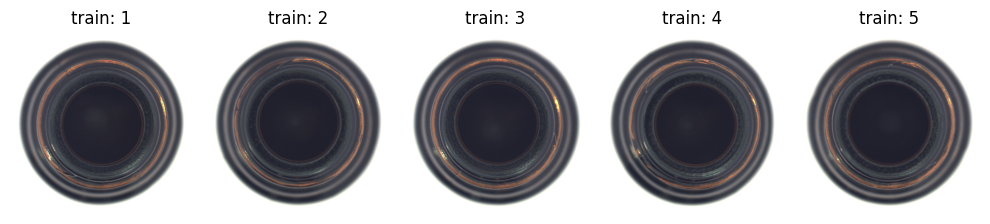

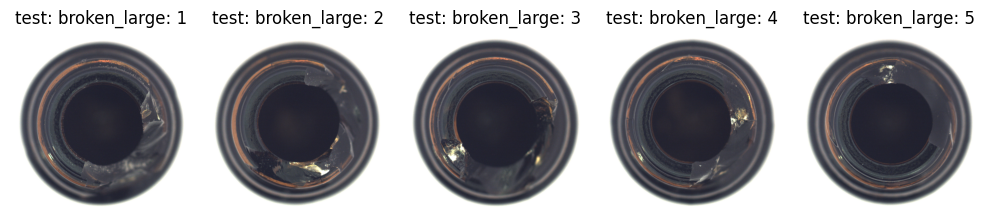

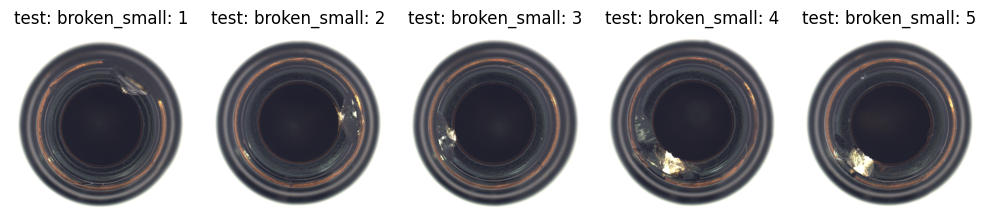

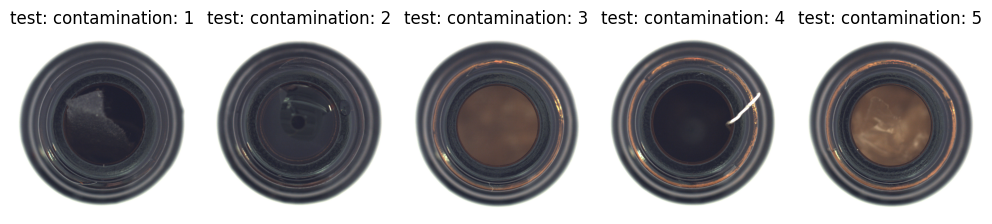

In [13]:

data_dir = "data/mvtec/bottle"
train_dir = os.path.join(data_dir, "train", "good")
test_dir = os.path.join(data_dir, "test")


def show_images(dir,title,n=5):
    images = random.sample(os.listdir(dir),n)
    plt.figure(figsize=(10,3))
    
    for number,img_name in enumerate(images):
        img = Image.open(os.path.join(dir,img_name))
        plt.subplot(1,n,number+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{title}: {number+1}")
    plt.tight_layout()
    plt.show()


show_images(train_dir,'train')

for flaw in os.listdir(test_dir):
    if flaw != 'good':
        path = os.path.join(test_dir,flaw)
        show_images(path,f"test: {flaw}")

In [14]:
from torch.utils.data import DataLoader
from src.dataset import BottleDataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3,(0.5,)*3)
])

train_data= BottleDataset(train_dir,transform)
train_loader= DataLoader(train_data,batch_size=32,shuffle=True)


In [15]:
import torch
from src.autoencoder import AutoEncoder
from torch import nn
from tqdm import tqdm


device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AutoEncoder().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
loss_fn = nn.MSELoss()

best_loss = float('inf')
epochs = 150

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader):
        batch = batch.to(device)
        output = model(batch)
        loss = loss_fn(output,batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss+=loss
    train_loss /= len(train_loader)
    print(f'Epoch: {epoch+1}, Train_loss: {train_loss:.4f}')
    if train_loss < best_loss:
        torch.save(model.state_dict(), "outputs/best_model.pth")
        print("Best model saved.")
        

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:03<00:00,  1.96it/s]


Epoch: 1, Train_loss: 0.5463
Best model saved.


100%|██████████| 7/7 [00:03<00:00,  2.01it/s]


Epoch: 2, Train_loss: 0.2992
Best model saved.


...

Epoch: 148, Train_loss: 0.0017
Best model saved.


100%|██████████| 7/7 [00:05<00:00,  1.19it/s]


Epoch: 149, Train_loss: 0.0018
Best model saved.


100%|██████████| 7/7 [00:04<00:00,  1.71it/s]

Epoch: 150, Train_loss: 0.0017
Best model saved.


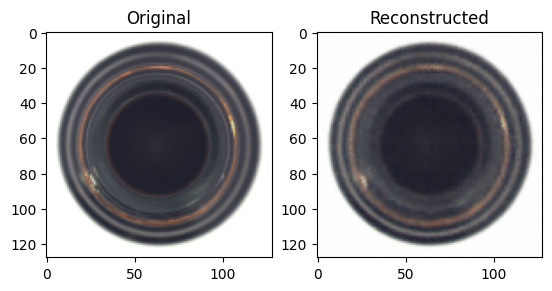

In [30]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))[0].unsqueeze(0).to(device)
    output = model(sample)

plt.subplot(1, 2, 1)
plt.imshow(sample.cpu().squeeze().permute(1, 2, 0) * 0.5 + 0.5)
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(output.cpu().squeeze().permute(1, 2, 0) * 0.5 + 0.5)
plt.title("Reconstructed")
plt.show()


In [31]:
from src.autoencoder import AutoEncoder

model = AutoEncoder().to(device)
model.load_state_dict(torch.load("outputs/best_model.pth",weights_only=True))
model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [32]:
test_img = {}

for folder in os.listdir(test_dir):
    test_data = BottleDataset(os.path.join(test_dir,folder),transform)
    test_loader = DataLoader(test_data,batch_size=1,shuffle=False)
    test_img[folder] = test_loader

In [33]:
errors = {}
with torch.no_grad():
    for folder,dataloader in test_img.items():
        errors[folder]=[]
        for img in dataloader:
            img = img.to(device)
            test_output = model(img)
            test_loss = nn.functional.mse_loss(test_output,img,reduction='mean')
            
            errors[folder].append(test_loss.item())



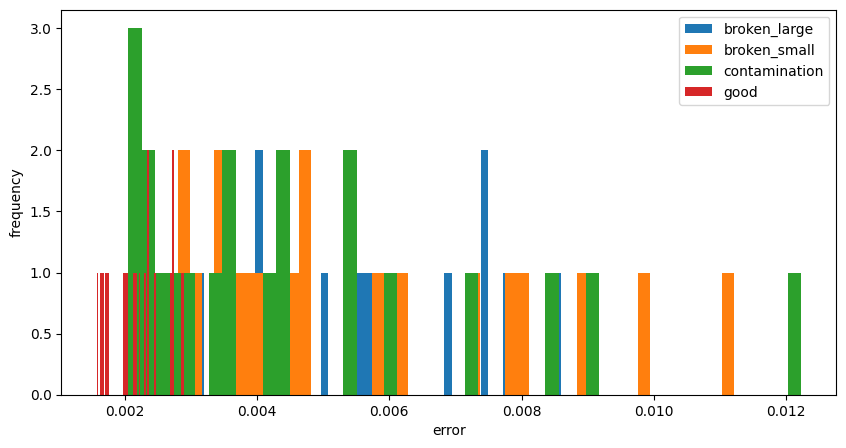

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for label,error in errors.items():
    plt.hist(error,bins=50,label=label)
plt.xlabel('error')
plt.ylabel('frequency')
plt.legend()

In [36]:
import numpy as np
threshold = max(errors['good'])



In [37]:
y_true = []
y_pred = []
for folder , error in errors.items():
    true_labels = 0 if folder=='good' else 1
    for err in error:
        y_true.append(true_labels)
        y_pred.append(1 if err > threshold else 0)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))
print(confusion_matrix(y_true, y_pred))


              precision    recall  f1-score   support

      Normal       0.62      1.00      0.77        20
     Anomaly       1.00      0.81      0.89        63

    accuracy                           0.86        83
   macro avg       0.81      0.90      0.83        83
weighted avg       0.91      0.86      0.86        83

[[20  0]
 [12 51]]


In [39]:
import gradio as gr
denorm = lambda x: (x * 0.5) + 0.5

def predict(image):
    image = image.convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(tensor)
        mse = nn.functional.mse_loss(output, tensor, reduction='mean').item()

    status = "Fine" if mse < threshold else "Broken"
    
    true = denorm(tensor.squeeze()).permute(1, 2, 0).cpu().numpy()
    pred = denorm(output.squeeze()).permute(1, 2, 0).cpu().numpy()
    
    return status, true, pred
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Textbox(label="result"),
        gr.Image(label="True"),
        gr.Image(label="reconstructed")
    ],
    title="Industrial Anomaly Detector",
)

interface.launch()


* Running on local URL:  http://127.0.0.1:7862

To create a public link, set `share=True` in `launch()`.
